In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import dataloader

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

trainDL = torch.utils.data.DataLoader(
    datasets.ImageFolder('data/Training', tf),
    batch_size = 32, shuffle=True, num_workers=4, pin_memory=True
)

testDL = torch.utils.data.DataLoader(
    datasets.ImageFolder('data/Testing', tf),
    batch_size = 32, shuffle=False, num_workers=4, pin_memory=True
)

In [3]:
model = nn.Sequential(
    nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128 * 16 * 16, 256), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(256, 4)
).to(device)

In [4]:
opt = optim.AdamW(model.parameters(), 1e-4)
lossFunc = nn.CrossEntropyLoss()

In [5]:
model.train()

for epoch in range(25):
    runningLoss = 0

    for x, y in trainDL:
        opt.zero_grad()
        currLoss = lossFunc(model(x.to(device)), y.to(device))
        currLoss.backward()
        runningLoss += currLoss
        opt.step()
    
    print(f"Epoch {epoch + 1} Loss: {runningLoss}")

Epoch 1 Loss: 154.2957763671875
Epoch 2 Loss: 104.04846954345703
Epoch 3 Loss: 89.26094818115234
Epoch 4 Loss: 77.26004791259766
Epoch 5 Loss: 69.26741027832031
Epoch 6 Loss: 61.112693786621094
Epoch 7 Loss: 55.542137145996094
Epoch 8 Loss: 49.430503845214844
Epoch 9 Loss: 44.22665023803711
Epoch 10 Loss: 39.09080123901367
Epoch 11 Loss: 35.00041961669922
Epoch 12 Loss: 30.170303344726562
Epoch 13 Loss: 27.970508575439453
Epoch 14 Loss: 25.319393157958984
Epoch 15 Loss: 22.24099349975586
Epoch 16 Loss: 19.596559524536133
Epoch 17 Loss: 18.76949119567871
Epoch 18 Loss: 15.257681846618652
Epoch 19 Loss: 14.373469352722168
Epoch 20 Loss: 13.221096992492676
Epoch 21 Loss: 12.29101276397705
Epoch 22 Loss: 10.825488090515137
Epoch 23 Loss: 10.155729293823242
Epoch 24 Loss: 9.311332702636719
Epoch 25 Loss: 7.66471004486084


In [6]:
model.eval()
testLoss, correct = 0, 0

with torch.no_grad():
    for x, y in testDL: 
        x, y = x.to(device), y.to(device)

        logits = model(x)
        testLoss += lossFunc(logits, y).item() * y.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
    
testLoss /= len(testDL.dataset)
accuracy = 100 * correct / len(testDL.dataset)

print(f"Test Loss: {testLoss}, Accuracy: {accuracy}%")

Test Loss: 1.1927430539950727, Accuracy: 90.25%


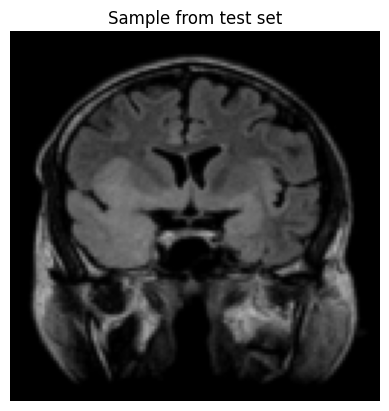

Predicted class: notumor, Actual class: notumor


In [13]:
import random 
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

model.eval()

idx = random.randrange(len(testDL.dataset))
img, label = testDL.dataset[idx]

unnorm = img * 0.5 + 0.5
plt.imshow(to_pil_image(unnorm))
plt.axis('off')
plt.title("Sample from test set")
plt.show()

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    pred = logits.argmax(1).item()

classNames = testDL.dataset.classes
print(f"Predicted class: {classNames[pred]}, Actual class: {classNames[label]}")